In [1]:
import pandas as pd
import numpy as np
import re
import tensorflow as tf
from tensorflow.keras.preprocessing.text import Tokenizer
from tensorflow.keras.preprocessing.sequence import pad_sequences
from tensorflow.keras.utils import to_categorical
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import Embedding, LSTM, Dense, Dropout, BatchNormalization, SpatialDropout1D
from tensorflow.keras.optimizers import Adam
from tensorflow.keras.callbacks import EarlyStopping, ReduceLROnPlateau
from sklearn.model_selection import train_test_split, StratifiedKFold
from sklearn.preprocessing import LabelEncoder
from sklearn.metrics import classification_report, confusion_matrix, roc_auc_score
import seaborn as sns
import matplotlib.pyplot as plt

In [2]:
# Load dataset
file_path = r"D:\AI and Data Science- Loyalist College\Term 3\NLP\Assignment 2\Sentiment_Data\Sentiment_Data.csv"
df = pd.read_csv(file_path, encoding="ISO-8859-1").dropna(subset=['Tweet'])

# Balance dataset: Ensure class balance by sampling 10,000 per class
df_sample = df.groupby('Sentiment', group_keys=False).apply(lambda x: x.sample(min(len(x), 6000), random_state=42))

# Text Cleaning Function (Handling Hashtags, Emojis)
def clean_text(text):
    text = text.lower()
    text = re.sub(r'@\w+', '', text)  # Remove mentions
    text = re.sub(r'http\S+|www.\S+', '', text)  # Remove URLs
    text = re.sub(r'#(\w+)', r'\1', text)  # Remove hashtags but keep words
    text = re.sub(r'[^a-z\s]', '', text)  # Remove special characters, emojis, and numbers
    text = re.sub(r'\s+', ' ', text).strip()  # Remove extra spaces
    return text

# Apply text cleaning
df_sample['Clean_Tweet'] = df_sample['Tweet'].apply(clean_text)

# Encode labels
label_encoder = LabelEncoder()
df_sample['Sentiment'] = label_encoder.fit_transform(df_sample['Sentiment'])
num_classes = len(label_encoder.classes_)

# Train-Test Split (80-20)
train_df, test_df = train_test_split(df_sample, test_size=0.2, stratify=df_sample['Sentiment'], random_state=42)

# Tokenization settings
MAX_NUM_WORDS = 30000  # Vocabulary size
MAX_SEQUENCE_LENGTH = 120  # Limit tweet length
EMBEDDING_DIM = 200  # GloVe embedding size

# Tokenizer
tokenizer = Tokenizer(num_words=MAX_NUM_WORDS, oov_token="<OOV>")
tokenizer.fit_on_texts(train_df['Clean_Tweet'])

# Convert text to sequences
X_train_seq = tokenizer.texts_to_sequences(train_df['Clean_Tweet'])
X_test_seq = tokenizer.texts_to_sequences(test_df['Clean_Tweet'])

# Pad sequences
X_train_padded = pad_sequences(X_train_seq, maxlen=MAX_SEQUENCE_LENGTH, padding='pre', truncating='pre')
X_test_padded = pad_sequences(X_test_seq, maxlen=MAX_SEQUENCE_LENGTH, padding='pre', truncating='pre')


In [3]:
# One-hot encode labels
y_train = to_categorical(train_df['Sentiment'], num_classes=num_classes)
y_test = to_categorical(test_df['Sentiment'], num_classes=num_classes)

# Load GloVe embeddings
embedding_index = {}
glove_file_path = r"D:\AI and Data Science- Loyalist College\Term 3\NLP\glove.6B.200d.txt"

with open(glove_file_path, encoding="utf-8") as f:
    for line in f:
        values = line.split()
        word = values[0]
        embedding_index[word] = np.array(values[1:], dtype='float32')

# Create embedding matrix
embedding_matrix = np.zeros((MAX_NUM_WORDS, EMBEDDING_DIM))
for word, i in tokenizer.word_index.items():
    if i < MAX_NUM_WORDS:
        embedding_vector = embedding_index.get(word)
        if embedding_vector is not None:
            embedding_matrix[i] = embedding_vector


In [4]:
# Build LSTM Model (Deep Unidirectional RNN)
model = Sequential([
    Embedding(input_dim=MAX_NUM_WORDS, output_dim=EMBEDDING_DIM, weights=[embedding_matrix], 
              input_length=MAX_SEQUENCE_LENGTH, trainable=True),  # Allow fine-tuning of embeddings

    SpatialDropout1D(0.3),  # Prevent overfitting

    LSTM(128, return_sequences=True, activation='tanh'),
    Dropout(0.3),

    LSTM(64, activation='tanh'),
    Dropout(0.3),

    Dense(32, activation='relu'),
    BatchNormalization(),  # Helps stabilize training
    Dropout(0.3),

    Dense(num_classes, activation='softmax')  # Multi-class classification
])

# Compile Model
model.compile(loss='categorical_crossentropy', optimizer=Adam(learning_rate=0.001), metrics=['accuracy'])

# Callbacks
early_stopping = EarlyStopping(monitor='val_loss', patience=8, restore_best_weights=True)
reduce_lr = ReduceLROnPlateau(monitor='val_loss', factor=0.5, patience=3, min_lr=1e-5)

C:\Users\dhrjd\AppData\Roaming\Python\Python311\site-packages\keras\src\layers\core\embedding.py:90: UserWarning: Argument `input_length` is deprecated. Just remove it.
  warnings.warn(


In [5]:

# Train Model
history = model.fit(X_train_padded, y_train, validation_data=(X_test_padded, y_test),
                    epochs=15, batch_size=64, callbacks=[early_stopping, reduce_lr], verbose=2)


Epoch 1/15
375/375 - 221s - 588ms/step - accuracy: 0.3178 - loss: 1.6027 - val_accuracy: 0.4242 - val_loss: 1.3566 - learning_rate: 0.0010
Epoch 2/15
375/375 - 261s - 696ms/step - accuracy: 0.4273 - loss: 1.3426 - val_accuracy: 0.4867 - val_loss: 1.2264 - learning_rate: 0.0010
Epoch 3/15
375/375 - 259s - 691ms/step - accuracy: 0.5099 - loss: 1.1933 - val_accuracy: 0.5267 - val_loss: 1.1577 - learning_rate: 0.0010
Epoch 4/15
375/375 - 265s - 706ms/step - accuracy: 0.5698 - loss: 1.0766 - val_accuracy: 0.5417 - val_loss: 1.1226 - learning_rate: 0.0010
Epoch 5/15
375/375 - 268s - 714ms/step - accuracy: 0.6196 - loss: 0.9642 - val_accuracy: 0.5522 - val_loss: 1.1347 - learning_rate: 0.0010
Epoch 6/15
375/375 - 270s - 720ms/step - accuracy: 0.6695 - loss: 0.8593 - val_accuracy: 0.5627 - val_loss: 1.1666 - learning_rate: 0.0010
Epoch 7/15
375/375 - 252s - 671ms/step - accuracy: 0.7175 - loss: 0.7481 - val_accuracy: 0.5715 - val_loss: 1.1823 - learning_rate: 0.0010
Epoch 8/15
375/375 - 258s -

188/188 ━━━━━━━━━━━━━━━━━━━━ 18s 92ms/step


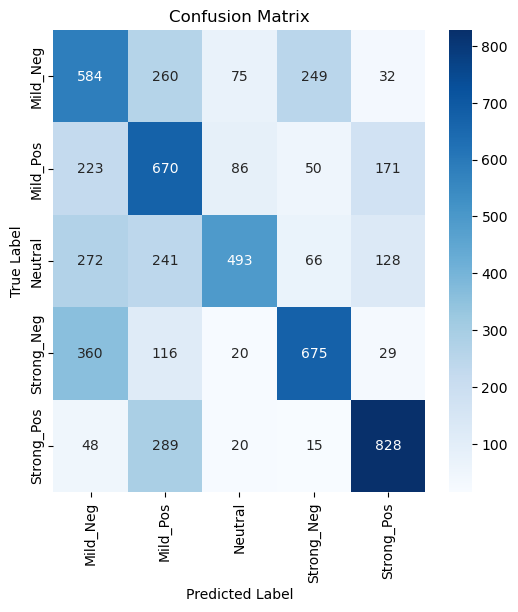

In [6]:
# Evaluate Model with Confusion Matrix & AUC
y_pred = model.predict(X_test_padded)
y_pred_classes = np.argmax(y_pred, axis=1)
y_test_classes = np.argmax(y_test, axis=1)

# Confusion Matrix
cm = confusion_matrix(y_test_classes, y_pred_classes)
plt.figure(figsize=(6,6))
sns.heatmap(cm, annot=True, fmt="d", cmap="Blues", xticklabels=label_encoder.classes_, yticklabels=label_encoder.classes_)
plt.xlabel("Predicted Label")
plt.ylabel("True Label")
plt.title("Confusion Matrix")
plt.show()

In [7]:
# Classification Report
print(classification_report(y_test_classes, y_pred_classes, target_names=label_encoder.classes_))

# AUC Score
auc_score = roc_auc_score(y_test, y_pred, multi_class='ovr')
print(f"AUC Score: {auc_score:.4f}")

              precision    recall  f1-score   support

    Mild_Neg       0.39      0.49      0.43      1200
    Mild_Pos       0.43      0.56      0.48      1200
     Neutral       0.71      0.41      0.52      1200
  Strong_Neg       0.64      0.56      0.60      1200
  Strong_Pos       0.70      0.69      0.69      1200

    accuracy                           0.54      6000
   macro avg       0.57      0.54      0.55      6000
weighted avg       0.57      0.54      0.55      6000

AUC Score: 0.8244


In [8]:
# Cross-Validation (StratifiedKFold for Robust Evaluation)
skf = StratifiedKFold(n_splits=5, shuffle=True, random_state=42)
cv_accuracies = []

In [9]:
for train_index, val_index in skf.split(X_train_padded, np.argmax(y_train, axis=1)):
    X_train_fold, X_val_fold = X_train_padded[train_index], X_train_padded[val_index]
    y_train_fold, y_val_fold = y_train[train_index], y_train[val_index]

    model.fit(X_train_fold, y_train_fold, validation_data=(X_val_fold, y_val_fold),
              epochs=5, batch_size=64, verbose=0)  # Run small epochs for CV
    
    fold_accuracy = model.evaluate(X_val_fold, y_val_fold, verbose=0)[1]
    cv_accuracies.append(fold_accuracy)

In [10]:
print(f"Cross-Validation Accuracies: {cv_accuracies}")
print(f"Mean CV Accuracy: {np.mean(cv_accuracies):.4f}")

Cross-Validation Accuracies: [0.6922916769981384, 0.7443749904632568, 0.7989583611488342, 0.8477083444595337, 0.8804166913032532]
Mean CV Accuracy: 0.7928
